In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\A.Arun Sundar\Downloads\loan_approval_dataset.csv")
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,Rejected
...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,Approved


In [3]:
df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' loan_status'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    loan_status               4269 non-null   object
dtypes: int64(7), object(3)
memory usage: 333.6+ KB


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 loan_status                 0
dtype: int64

In [7]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07


In [8]:
df.drop(columns='loan_id',axis=1,inplace=True)

In [9]:
df.columns=df.columns.str.strip()

In [10]:
df.rename(columns={'residential_assets_value':'residential'},inplace=True)

In [11]:
df

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,Rejected
...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,Yes,1000000,2300000,12,317,2800000,Rejected
4265,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,Approved
4266,2,Not Graduate,No,6500000,23900000,18,457,1200000,Rejected
4267,1,Not Graduate,No,4100000,12800000,8,780,8200000,Approved


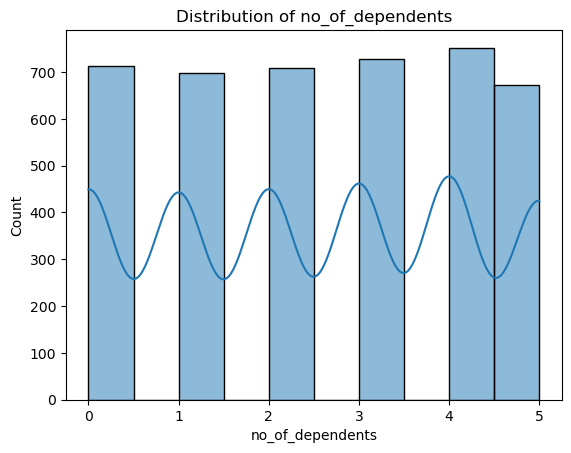

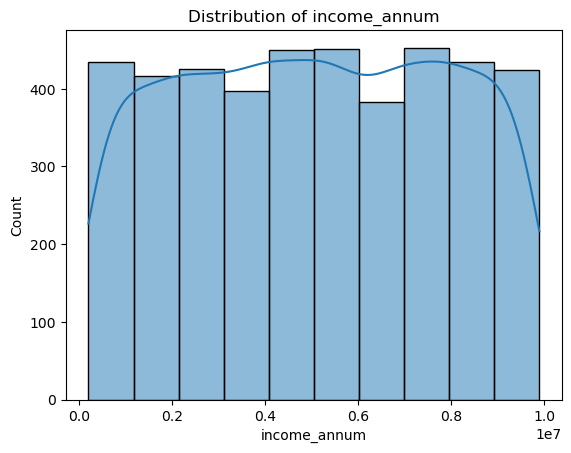

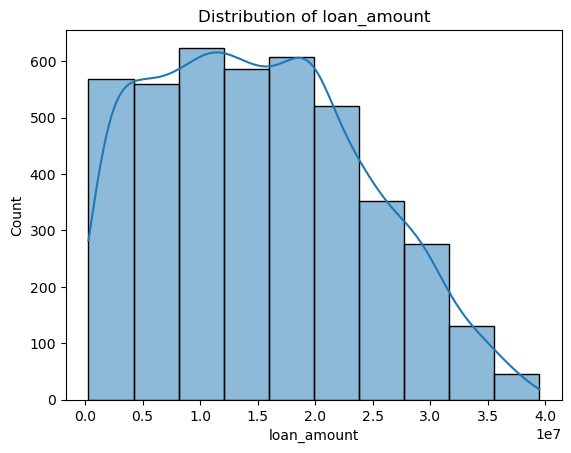

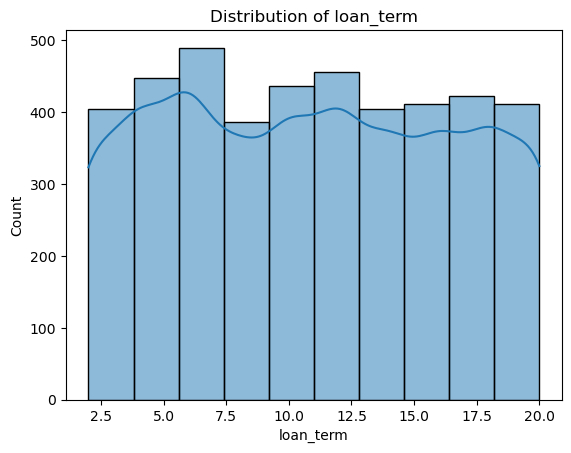

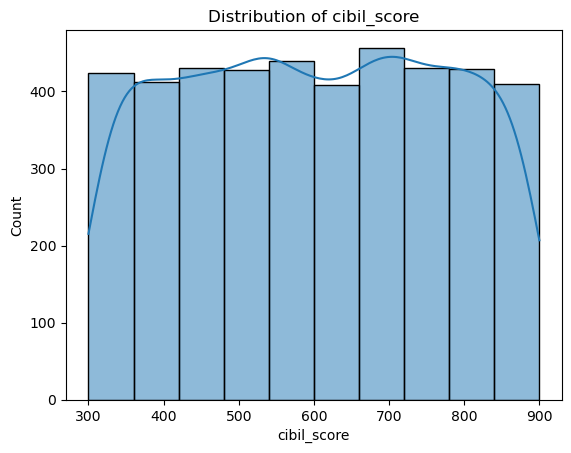

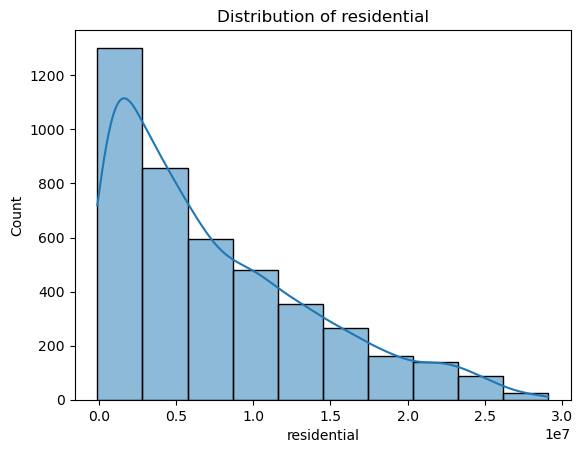

In [12]:
number=df.select_dtypes(include=[int,float])
for col in number.columns:
    sns.histplot(data=df, x=col, bins=10, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

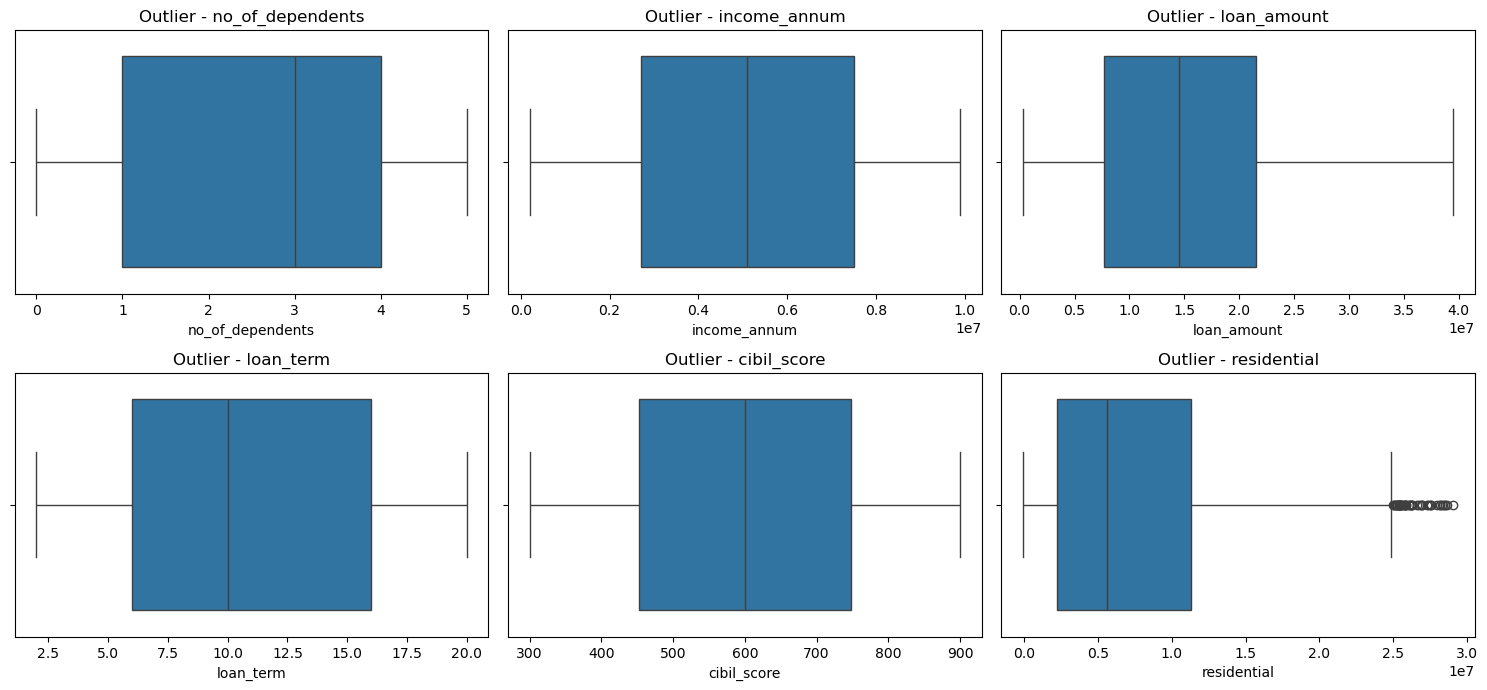

In [13]:
num = df.select_dtypes(include=['int', 'float'])
cols = num.columns
n = len(cols)
plt.figure(figsize=(15, 10))
for i, col in enumerate(cols, 1):
    plt.subplot((n//3)+1, 3, i) 
    sns.boxplot(data=df,x=col)
    plt.title(f"Outlier - {col}")
plt.tight_layout()
plt.show()

In [14]:
q1=df['residential'].quantile(0.25)
q3=df['residential'].quantile(0.75)
IQR=q3-q1
lower=q1-1.5*IQR
high=q3+1.5*IQR
df['residential']=df['residential'].clip(lower,high)

Text(0.5, 1.0, 'Residential')

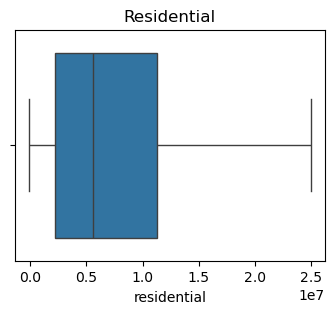

In [15]:
plt.figure(figsize=(4,3))
sns.boxplot(data=df,x='residential')
plt.title("Residential")

C:\Users\A.Arun Sundar\AppData\Local\Temp\ipykernel_21116\820385884.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='loan_status',palette="Set1")


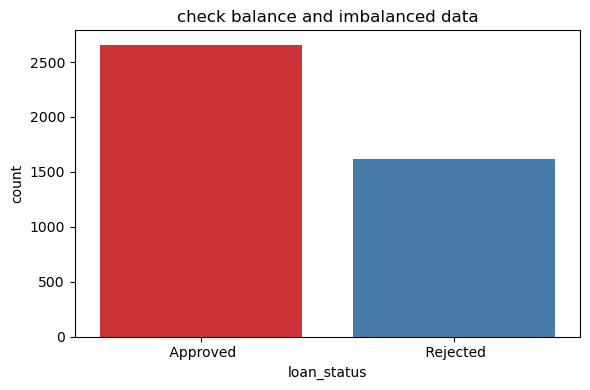

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x='loan_status',palette="Set1")
plt.title("check balance and imbalanced data")
plt.tight_layout()
plt.show()

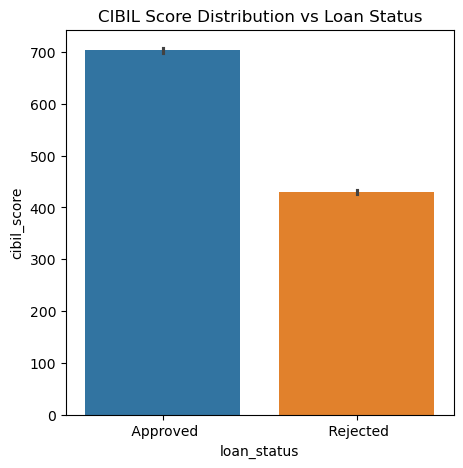

In [17]:
plt.figure(figsize=(5,5))
sns.barplot(x='loan_status', y='cibil_score', data=df,hue='loan_status')
plt.title("CIBIL Score Distribution vs Loan Status")
plt.show()

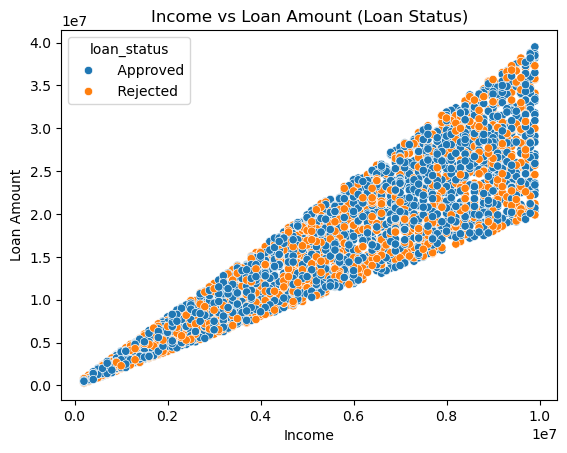

In [18]:
sns.scatterplot(
    data=df,
    x='income_annum',
    y='loan_amount',
    hue='loan_status'
)
plt.title("Income vs Loan Amount (Loan Status)")
plt.xlabel("Income")
plt.ylabel("Loan Amount")
plt.show()

In [19]:
df.drop(columns=['education'],axis=1,inplace=True)

In [20]:
df.drop(columns=['no_of_dependents'],axis=1,inplace=True)

In [21]:
df.columns

Index(['self_employed', 'income_annum', 'loan_amount', 'loan_term',
       'cibil_score', 'residential', 'loan_status'],
      dtype='object')

In [22]:
from sklearn.preprocessing import LabelEncoder
lb=LabelEncoder()
df['loan_status']=lb.fit_transform(df['loan_status'])# approved 0,rejected 1

In [23]:
from sklearn.preprocessing import LabelEncoder
lb=LabelEncoder()
df['self_employed']=lb.fit_transform(df['self_employed'])

<Axes: >

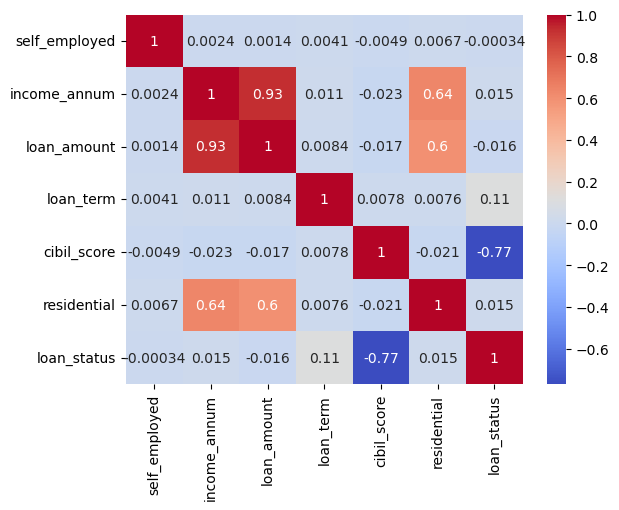

In [24]:
corr=df.select_dtypes(include=[int,float]).corr()
sns.heatmap(data=corr,annot=True,cmap='coolwarm')

In [25]:
df

,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential,loan_status
0,0,9600000,29900000,12,778,2400000,0
1,1,4100000,12200000,8,417,2700000,1
2,0,9100000,29700000,20,506,7100000,1
3,0,8200000,30700000,8,467,18200000,1
4,1,9800000,24200000,20,382,12400000,1
...,...,...,...,...,...,...,...
4264,1,1000000,2300000,12,317,2800000,1
4265,1,3300000,11300000,20,559,4200000,0
4266,0,6500000,23900000,18,457,1200000,1
4267,0,4100000,12800000,8,780,8200000,0


In [26]:
from sklearn.feature_selection import SelectKBest , f_classif
x=df.drop(columns='loan_status')
y=df['loan_status']

In [27]:
select=SelectKBest(score_func=f_classif,k=5)
features=select.fit_transform(x,y)
print("important features:",x.columns[select.get_support()])

important features: Index(['income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential'],
      dtype='object')


In [28]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [29]:
from imblearn.over_sampling import SMOTE
sm=SMOTE()
x_res,y_res=sm.fit_resample(x_train,y_train)

In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [31]:
models = {
    'Decision Tree': DecisionTreeClassifier(criterion='entropy', max_depth=2),
    'Random Forest': RandomForestClassifier(n_estimators=50, max_depth=4),
    'Logistic Regression': LogisticRegression()
}

In [37]:
for name,model in models.items():
    model.fit(x_res,y_res)
    y_pred=model.predict(x_test)
    print("Model_Name:",name)
    print("confusion Matrix:",confusion_matrix(y_test,y_pred))
    print("report",classification_report(y_test,y_pred))
    print("______________________________________________________________________________________")
    

Model_Name: Decision Tree
confusion Matrix: [[500  36]
 [  1 317]]
report               precision    recall  f1-score   support

           0       1.00      0.93      0.96       536
           1       0.90      1.00      0.94       318

    accuracy                           0.96       854
   macro avg       0.95      0.96      0.95       854
weighted avg       0.96      0.96      0.96       854

______________________________________________________________________________________
Model_Name: Random Forest
confusion Matrix: [[505  31]
 [  6 312]]
report               precision    recall  f1-score   support

           0       0.99      0.94      0.96       536
           1       0.91      0.98      0.94       318

    accuracy                           0.96       854
   macro avg       0.95      0.96      0.95       854
weighted avg       0.96      0.96      0.96       854

______________________________________________________________________________________
Model_Name: Logistic Reg